In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pyvis.network import Network
import community.community_louvain as community_louvain
import networkx as nx
import seaborn as sns

In [2]:
df = pd.read_csv("subreddit_similarity_results.csv")

In [3]:
df['pair'] = df.apply(lambda row: tuple(sorted([row['Subreddit_A'], row['Subreddit_B']])), axis=1)

df_unique = df.drop_duplicates(subset='pair')

In [4]:
threshold = df['Similarity_Score'].quantile(0.97)
top_pairs = df_unique[df_unique['Similarity_Score'] >= threshold]

In [14]:

G = nx.from_pandas_edgelist(
    top_pairs,
    source='Subreddit_A',
    target='Subreddit_B',
    edge_attr='Similarity_Score'
)

for u, v, d in G.edges(data=True):
    d['value'] = d['Similarity_Score']
    if d['Similarity_Score'] > 0.90:
        d['color'] = 'red'

degree_dict = dict(G.degree())

for node in G.nodes():
    G.nodes[node]['size'] = max(degree_dict[node] * 3, 5)
partition = community_louvain.best_partition(G, weight='Similarity_Score', resolution=1.0)
modularity = community_louvain.modularity(partition, G, weight='Similarity_Score')

In [15]:
from collections import defaultdict
import pandas as pd


community_nodes = defaultdict(list)
for node, community_id in partition.items():
    community_nodes[community_id].append(node)


weighted_degree = dict(G.degree(weight="Similarity_Score"))
degree = dict(G.degree())

def top_subreddits_in_community(nodes, n=2):
    ranked = sorted(
        nodes,
        key=lambda node: weighted_degree.get(node, 0),
        reverse=True
    )
    return ranked[:n]

community_labels = {
    community_id: " / ".join(top_subreddits_in_community(nodes, n=2))
    for community_id, nodes in community_nodes.items()
}

community_summary = pd.DataFrame([
    {
        "community": community_id,
        "community_name": community_labels[community_id],
        "num_subreddits": len(nodes),
        "top_subreddits": ", ".join(top_subreddits_in_community(nodes, n=5))
    }
    for community_id, nodes in community_nodes.items()
]).sort_values("num_subreddits", ascending=False)
print(f"Total communities: {len(community_summary)}")



Total communities: 91


In [16]:
from collections import defaultdict

community_nodes = defaultdict(list)
for node, community_id in partition.items():
    community_nodes[community_id].append(node)

communities = dict(community_nodes)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import colormaps
from pyvis.network import Network

# Map each subreddit/node to its detected community id.
node_to_community = partition.copy()

community_sizes = pd.Series(node_to_community).value_counts().sort_index()
display(
    community_sizes
    .rename_axis("community")
    .reset_index(name="num_subreddits")
    .sort_values("num_subreddits", ascending=False)
    .head(20)
)


palette = [
    "#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
    "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC",
    "#1F77B4", "#FF7F0E", "#2CA02C", "#D62728", "#9467BD",
    "#8C564B", "#E377C2", "#7F7F7F", "#BCBD22", "#17BECF",
]
community_color = {
    community_id: palette[rank % len(palette)]
    for rank, community_id in enumerate(community_sizes.sort_values(ascending=False).index)
}

degree_dict = dict(G.degree())

for node in G.nodes():
    community_id = node_to_community[node]
    G.nodes[node]["group"] = int(community_id)
    G.nodes[node]["color"] = community_color[community_id]
    G.nodes[node]["size"] = max(degree_dict[node] * 2.5, 8)
    G.nodes[node]["title"] = (
        f"Subreddit: {node}<br>"
        f"Community: {community_id}<br>"
        f"Degree: {degree_dict[node]}"
    )

for _, _, edge_data in G.edges(data=True):
    score = edge_data.get("Similarity_Score", 0)
    edge_data["value"] = score
    edge_data["title"] = f"Similarity: {score:.4f}"
    edge_data["color"] = "rgba(180, 180, 180, 0.22)"

community_net = Network(
    height="850px",
    width="100%",
    bgcolor="#111111",
    font_color="white",
    notebook=False,
    cdn_resources="in_line",
)

community_net.from_nx(G)
community_net.force_atlas_2based(
    gravity=-45,
    central_gravity=0.01,
    spring_length=130,
    spring_strength=0.08,
    damping=0.4,
)
community_net.show_buttons(filter_=["physics"])

html = community_net.generate_html()

with open("subreddit_community_graph.html", "w", encoding="utf-8") as f:
    f.write(html)

print("Saved interactive community graph to subreddit_community_graph.html")


,community,num_subreddits
0,0,593
9,9,380
27,27,353
43,43,293
21,21,218
54,54,214
24,24,190
14,14,169
68,68,104
36,36,102


In [17]:
from collections import defaultdict
import networkx as nx
import pandas as pd
from pyvis.network import Network

TOP_LABEL_SUBREDDITS = 3
MIN_COMMUNITY_SIZE_FOR_META_GRAPH = 3
TOP_COMMUNITY_EDGES = 120

# Use H if you already ran Bridge/Gateway cells; otherwise fall back to G.
base_graph = H if "H" in globals() else G
base_degree = dict(base_graph.degree(weight="Similarity_Score"))

community_nodes_meta = {
    community_id: set(nodes) & set(base_graph.nodes())
    for community_id, nodes in communities.items()
}
community_nodes_meta = {
    community_id: nodes
    for community_id, nodes in community_nodes_meta.items()
    if len(nodes) >= MIN_COMMUNITY_SIZE_FOR_META_GRAPH
}

node_to_meta_community = {
    node: community_id
    for community_id, nodes in community_nodes_meta.items()
    for node in nodes
}

def top_subreddits_for_label(nodes, n=TOP_LABEL_SUBREDDITS):
    ranked = sorted(nodes, key=lambda node: base_degree.get(node, 0), reverse=True)
    return ranked[:n]

community_labels = {}
community_tooltips = {}

for community_id, nodes in community_nodes_meta.items():
    top_subreddits = top_subreddits_for_label(nodes)
    community_labels[community_id] = " / ".join(top_subreddits)
    sample_subreddits = top_subreddits_for_label(nodes, n=12)
    community_tooltips[community_id] = (
        f"Community {community_id}<br>"
        f"Size: {len(nodes)} subreddits<br>"
        f"Top subreddits: {', '.join(sample_subreddits)}"
    )

# Aggregate subreddit-level edges into community-level edges.
edge_stats = defaultdict(lambda: {"weight_sum": 0.0, "edge_count": 0, "max_similarity": 0.0})

for u, v, data in base_graph.edges(data=True):
    cu = node_to_meta_community.get(u)
    cv = node_to_meta_community.get(v)
    if cu is None or cv is None or cu == cv:
        continue

    a, b = sorted((cu, cv))
    similarity = data.get("Similarity_Score", data.get("weight", 1.0))
    edge_stats[(a, b)]["weight_sum"] += similarity
    edge_stats[(a, b)]["edge_count"] += 1
    edge_stats[(a, b)]["max_similarity"] = max(edge_stats[(a, b)]["max_similarity"], similarity)

community_edge_columns = [
    "source_community",
    "target_community",
    "weight_sum",
    "edge_count",
    "avg_similarity",
    "max_similarity",
    "source_label",
    "target_label",
]

community_edge_df = pd.DataFrame([
    {
        "source_community": source,
        "target_community": target,
        "weight_sum": stats["weight_sum"],
        "edge_count": stats["edge_count"],
        "avg_similarity": stats["weight_sum"] / stats["edge_count"],
        "max_similarity": stats["max_similarity"],
        "source_label": community_labels[source],
        "target_label": community_labels[target],
    }
    for (source, target), stats in edge_stats.items()
], columns=community_edge_columns).sort_values(["weight_sum", "edge_count"], ascending=False)

display(community_edge_df.head(20))

selected_edges = community_edge_df.head(TOP_COMMUNITY_EDGES)
selected_communities = set(selected_edges["source_community"]) | set(selected_edges["target_community"])

community_graph = nx.Graph()

for community_id in selected_communities:
    nodes = community_nodes_meta[community_id]
    community_graph.add_node(
        int(community_id),
        label=community_labels[community_id],
        title=community_tooltips[community_id],
        size=max(18, min(75, 10 + len(nodes) * 0.9)),
        value=len(nodes),
    )

for row in selected_edges.itertuples(index=False):
    community_graph.add_edge(
        int(row.source_community),
        int(row.target_community),
        value=max(1, row.weight_sum),
        width=max(1, min(12, row.edge_count ** 0.5)),
        title=(
            f"{row.source_label} ↔ {row.target_label}<br>"
            f"Connections: {row.edge_count}<br>"
            f"Total similarity: {row.weight_sum:.2f}<br>"
            f"Avg similarity: {row.avg_similarity:.4f}<br>"
            f"Max similarity: {row.max_similarity:.4f}"
        ),
    )

community_level_net = Network(
    height="850px",
    width="100%",
    bgcolor="#111111",
    font_color="white",
    notebook=False,
    cdn_resources="in_line",
)

community_level_net.from_nx(community_graph)
community_level_net.force_atlas_2based(
    gravity=-70,
    central_gravity=0.015,
    spring_length=180,
    spring_strength=0.06,
    damping=0.5,
)
community_level_net.show_buttons(filter_=["physics"])

legend_html = """
<div style='position:absolute;top:12px;left:12px;z-index:999;background:#181818;color:white;padding:12px 14px;border:1px solid #444;font-family:Arial;font-size:14px;line-height:1.55'>
  <b>Community-Level Graph</b><br>
  Node = detected community<br>
  Label = most central subreddits<br>
  Edge = aggregated inter-community similarity<br>
</div>
"""

html = community_level_net.generate_html()
html = html.replace("<body>", "<body>" + legend_html)

with open("community_level_graph.html", "w", encoding="utf-8") as f:
    f.write(html)

print("Saved interactive community-level graph to community_level_graph.html")


,source_community,target_community,weight_sum,edge_count,avg_similarity,max_similarity,source_label,target_label
8,0,27,5240.7384,6754,0.775946,0.9598,AgencySquad / 0sanitymemes / ATBandATGcommunity,ArcaneOdyssey / AccurateBattleSim / Borderlands2
3,7,9,1458.7916,1856,0.785987,0.9556,BearsNSFWLikes / ClappingDemCheeks / Cholansfw,AI_Girl / ChandigarhGW / AInsfw
4,0,7,1257.2835,1639,0.767104,0.8877,AgencySquad / 0sanitymemes / ATBandATGcommunity,BearsNSFWLikes / ClappingDemCheeks / Cholansfw
1,0,14,1101.7918,1425,0.773187,0.9700,AgencySquad / 0sanitymemes / ATBandATGcommunity,AnimalCrossing / BabyYoda / CatsBeingCats
2,0,9,1045.8924,1366,0.765661,0.9543,AgencySquad / 0sanitymemes / ATBandATGcommunity,AI_Girl / ChandigarhGW / AInsfw
16,0,10,725.4639,947,0.766065,0.9178,AgencySquad / 0sanitymemes / ATBandATGcommunity,AJR / 5sos / BlackCountryNewRoad
11,0,21,380.1292,483,0.787017,0.9609,AgencySquad / 0sanitymemes / ATBandATGcommunity,Anarcho_Capitalism / AskThe_Donald / BidenBuzz
30,23,27,212.2566,276,0.769046,0.9399,CarXStreets / C8Corvette / 2011,ArcaneOdyssey / AccurateBattleSim / Borderlands2
19,14,27,195.8002,255,0.767844,0.8940,AnimalCrossing / BabyYoda / CatsBeingCats,ArcaneOdyssey / AccurateBattleSim / Borderlands2
10,0,40,184.1903,241,0.764275,0.9307,AgencySquad / 0sanitymemes / ATBandATGcommunity,Bellingham / Bend / Charlottesville


Saved interactive community-level graph to community_level_graph.html


,community,size,internal_edges,possible_edges,density,avg_internal_similarity,median_internal_similarity,external_edges,external_ratio,top_subreddits,density_type
2,2,3,3,3,1.000000,0.980333,0.97220,0,0.000000,AxieInfinityScholar / AxieScholarshipsPH / Axi...,Dense
23,29,3,3,3,1.000000,0.970400,0.97260,0,0.000000,CasualIT / Avvocati / BancaDelMeme,Dense
11,12,6,15,15,1.000000,0.946387,0.96600,0,0.000000,China_irl / Chinatown_irl / CLTV / 4832 / Asia...,Dense
24,31,3,3,3,1.000000,0.910533,0.89170,1,0.142857,Afghan / AfghanCivilwar / AfghanConflict,Dense
27,37,3,3,3,1.000000,0.890000,0.88030,0,0.000000,ChristmasDecorating / ChristmasTrees / Christm...,Dense
10,11,7,21,21,1.000000,0.880800,0.87860,0,0.000000,AskFrance / AskMec / CestQuoiCeTruc / AskMeuf ...,Dense
29,42,5,10,10,1.000000,0.850530,0.82285,0,0.000000,Aalborg / Aarhus / Bergen / Allsvenskan / Asks...,Dense
35,51,3,3,3,1.000000,0.837167,0.79610,0,0.000000,CornishFeed / CatalanFeed / BengaliFeed,Dense
31,44,3,3,3,1.000000,0.830200,0.78780,0,0.000000,Centrelink / CentrelinkOz / BenefitsAdviceUK,Dense
46,71,3,3,3,1.000000,0.823233,0.82390,0,0.000000,BlackPink / Aespa / BABYMONSTER,Dense


,community,size,internal_edges,possible_edges,density,avg_internal_similarity,median_internal_similarity,external_edges,external_ratio,top_subreddits,density_type
12,30,217,1031,23436,0.043992,0.806026,0.79080,191,0.084776,AvPD / BPDlite / AuDHDWomen / BorderlinePDisor...,Sparse
18,21,217,1648,23436,0.070319,0.815105,0.80335,535,0.139650,Anarcho_Capitalism / AskThe_Donald / BidenBuzz...,Sparse
4,4,100,452,4950,0.091313,0.807703,0.79175,103,0.102284,Cannabis_Culture / CannabisGrowers / ColdFire ...,Sparse
17,23,309,4696,47586,0.098684,0.815553,0.81085,452,0.045916,CarXStreets / C8Corvette / 2011 / CarParkingMu...,Sparse
20,40,186,2200,17205,0.127870,0.807101,0.79825,309,0.065619,Bellingham / Bend / Charlottesville / Bozeman ...,Sparse
0,0,598,23223,178503,0.130099,0.790335,0.78000,13215,0.221501,AgencySquad / 0sanitymemes / ATBandATGcommunit...,Sparse
3,65,104,968,5356,0.180732,0.800681,0.78595,53,0.026647,CoinMarketCap / CoinTuta / BNBTrader / ASX_Bet...,Sparse
21,27,364,13394,66066,0.202737,0.792639,0.78340,7479,0.218257,ArcaneOdyssey / AccurateBattleSim / Borderland...,Sparse
14,15,21,43,210,0.204762,0.811900,0.79110,14,0.140000,Christianity / BibleVerseCommentary / Christia...,Sparse
13,14,156,2506,12090,0.207279,0.817043,0.80370,1967,0.281846,AnimalCrossing / BabyYoda / CatsBeingCats / Ba...,Sparse


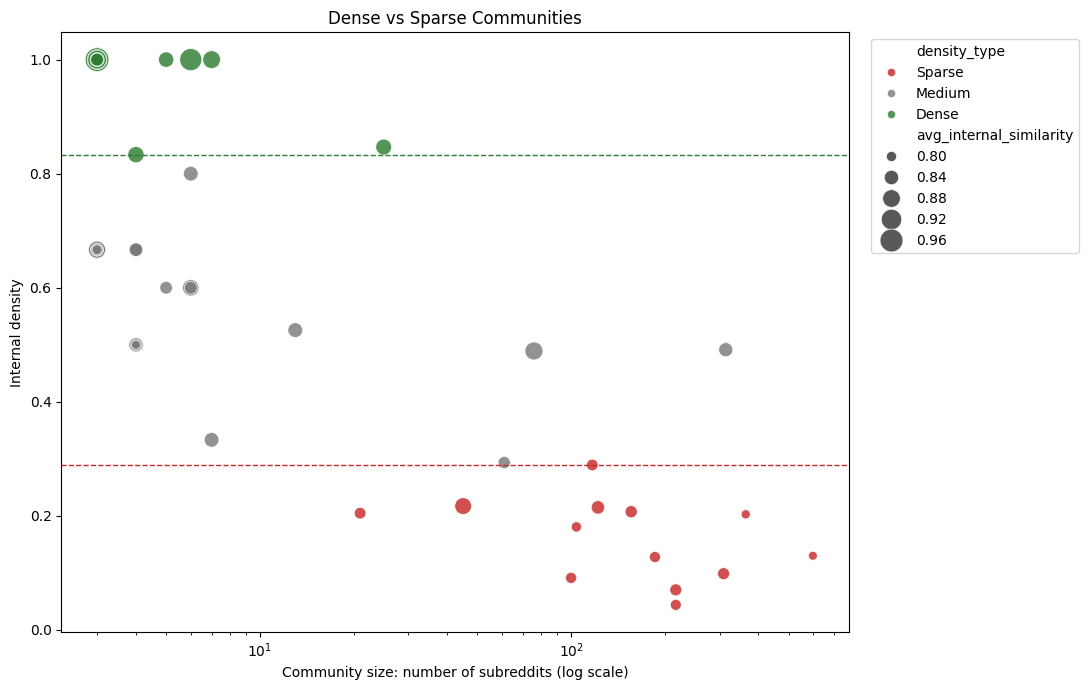

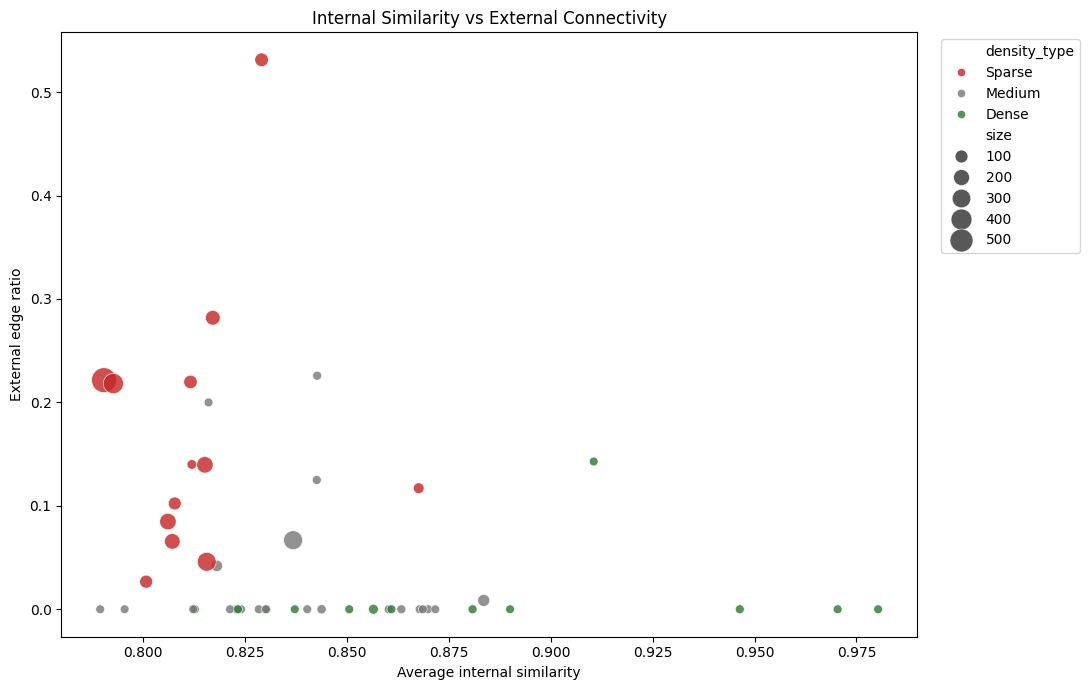

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MIN_COMMUNITY_SIZE_FOR_DENSITY = 3
DENSE_TOP_QUANTILE = 0.75
SPARSE_BOTTOM_QUANTILE = 0.25

base_graph = H if "H" in globals() else G
base_degree = dict(base_graph.degree(weight="Similarity_Score"))

community_density_rows = []

for community_id, community in communities.items():
    nodes = set(community) & set(base_graph.nodes())
    n = len(nodes)
    if n < MIN_COMMUNITY_SIZE_FOR_DENSITY:
        continue

    subgraph = base_graph.subgraph(nodes)
    internal_edges = subgraph.number_of_edges()
    possible_edges = n * (n - 1) / 2
    density = internal_edges / possible_edges if possible_edges else 0

    internal_weights = [
        data.get("Similarity_Score", data.get("weight", 1.0))
        for _, _, data in subgraph.edges(data=True)
    ]
    avg_internal_similarity = np.mean(internal_weights) if internal_weights else 0
    median_internal_similarity = np.median(internal_weights) if internal_weights else 0

    external_edges = 0
    external_weight_sum = 0
    for node in nodes:
        for neighbor, edge_data in base_graph[node].items():
            if neighbor not in nodes:
                external_edges += 1
                external_weight_sum += edge_data.get("Similarity_Score", edge_data.get("weight", 1.0))

    external_ratio = external_edges / (internal_edges * 2 + external_edges) if (internal_edges or external_edges) else 0
    top_subreddits = sorted(nodes, key=lambda node: base_degree.get(node, 0), reverse=True)[:5]

    community_density_rows.append({
        "community": community_id,
        "size": n,
        "internal_edges": internal_edges,
        "possible_edges": int(possible_edges),
        "density": density,
        "avg_internal_similarity": avg_internal_similarity,
        "median_internal_similarity": median_internal_similarity,
        "external_edges": external_edges,
        "external_ratio": external_ratio,
        "top_subreddits": " / ".join(top_subreddits),
    })

community_density_columns = [
    "community",
    "size",
    "internal_edges",
    "possible_edges",
    "density",
    "avg_internal_similarity",
    "median_internal_similarity",
    "external_edges",
    "external_ratio",
    "top_subreddits",
]

community_density_df = pd.DataFrame(community_density_rows, columns=community_density_columns)

dense_threshold = community_density_df["density"].quantile(DENSE_TOP_QUANTILE)
sparse_threshold = community_density_df["density"].quantile(SPARSE_BOTTOM_QUANTILE)

community_density_df["density_type"] = np.select(
    [
        community_density_df["density"] >= dense_threshold,
        community_density_df["density"] <= sparse_threshold,
    ],
    ["Dense", "Sparse"],
    default="Medium",
)

display(
    community_density_df
    .sort_values(["density", "avg_internal_similarity", "size"], ascending=False)
    .head(15)
)

display(
    community_density_df
    .sort_values(["density", "avg_internal_similarity", "size"], ascending=True)
    .head(15)
)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=community_density_df,
    x="size",
    y="density",
    hue="density_type",
    size="avg_internal_similarity",
    sizes=(40, 300),
    palette={"Dense": "#2E7D32", "Medium": "#7A7A7A", "Sparse": "#C62828"},
    alpha=0.82,
)
plt.xscale("log")
plt.axhline(dense_threshold, color="#2E7D32", linestyle="--", linewidth=1)
plt.axhline(sparse_threshold, color="#C62828", linestyle="--", linewidth=1)
plt.title("Dense vs Sparse Communities")
plt.xlabel("Community size: number of subreddits (log scale)")
plt.ylabel("Internal density")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=community_density_df,
    x="avg_internal_similarity",
    y="external_ratio",
    hue="density_type",
    size="size",
    sizes=(40, 320),
    palette={"Dense": "#2E7D32", "Medium": "#7A7A7A", "Sparse": "#C62828"},
    alpha=0.82,
)
plt.title("Internal Similarity vs External Connectivity")
plt.xlabel("Average internal similarity")
plt.ylabel("External edge ratio")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [21]:
df = pd.read_csv("result/highway_result.csv")

In [20]:
df

,rank,highway_length,highway_nodes,highway_tuple,occurrence_count,pct_of_paths,pct_of_paths_min_length,unique_communities_spanned
0,1,2,ConservativeKiwi → CapeIndependence,"('ConservativeKiwi', 'CapeIndependence')",22,8.70,100.00,2
1,2,2,2islamist4you → Afghan,"('2islamist4you', 'Afghan')",21,8.30,100.00,2
2,3,2,Barber → BeardAdvice,"('Barber', 'BeardAdvice')",20,7.91,100.00,2
3,4,2,90DayFiance → Celebrity_Fantasies2,"('90DayFiance', 'Celebrity_Fantasies2')",18,7.11,100.00,2
4,5,2,BlackHair → Barber,"('BlackHair', 'Barber')",17,6.72,100.00,1
...,...,...,...,...,...,...,...,...
75,16,5,BundaBoa → CelebsARG_ → Cholansfw → Anna_Faith...,"('BundaBoa', 'CelebsARG_', 'Cholansfw', 'Anna_...",2,1.28,61.66,3
76,17,5,BikiniBottomTwitter → AmazonWFShoppers → Aliex...,"('BikiniBottomTwitter', 'AmazonWFShoppers', 'A...",2,1.28,61.66,2
77,18,5,BalisongSale → BloxFruitsTrades → AdoptMeTradi...,"('BalisongSale', 'BloxFruitsTrades', 'AdoptMeT...",2,1.28,61.66,2
78,19,5,AmazonSeller → Buyee → Aliexpress → AmazonWFSh...,"('AmazonSeller', 'Buyee', 'Aliexpress', 'Amazo...",2,1.28,61.66,2


,rank,highway_length,highway_nodes,highway_tuple,occurrence_count,pct_of_paths,pct_of_paths_min_length,unique_communities_spanned,highway_label,cumulative_pct_of_paths
0,1,2,ConservativeKiwi → CapeIndependence,"('ConservativeKiwi', 'CapeIndependence')",22,8.70,100.00,2,ConservativeKiwi → CapeIndependence,8.70
1,1,3,BlackHair → Barber → BeardAdvice,"('BlackHair', 'Barber', 'BeardAdvice')",17,7.00,96.05,2,BlackHair → Barber → BeardAdvice,15.70
2,1,5,AdoptMeTrading → AdoptMeTradingRoblox → BloxFr...,"('AdoptMeTrading', 'AdoptMeTradingRoblox', 'Bl...",9,5.77,61.66,2,AdoptMeTrading → AdoptMeTradingRoblox → BloxFr...,21.47
3,1,4,AimeLeonDore → Athleta_gap → BlackestFridayDea...,"('AimeLeonDore', 'Athleta_gap', 'BlackestFrida...",14,6.28,88.14,2,AimeLeonDore → Athleta_gap → BlackestFridayDea...,27.75
4,2,4,AmazonWFShoppers → Aliexpress → Buyee → Amazon...,"('AmazonWFShoppers', 'Aliexpress', 'Buyee', 'A...",12,5.38,88.14,2,AmazonWFShoppers → Aliexpress → Buyee → Amazon...,33.13
5,2,5,ATBandATGcommunity → ButchSelfies → BlackHair ...,"('ATBandATGcommunity', 'ButchSelfies', 'BlackH...",9,5.77,61.66,3,ATBandATGcommunity → ButchSelfies → BlackHair ...,38.90
6,2,3,Athleta_gap → BlackestFridayDeals → BestThings,"('Athleta_gap', 'BlackestFridayDeals', 'BestTh...",16,6.58,96.05,2,Athleta_gap → BlackestFridayDeals → BestThings,45.48
7,2,2,2islamist4you → Afghan,"('2islamist4you', 'Afghan')",21,8.30,100.00,2,2islamist4you → Afghan,53.78
8,3,2,Barber → BeardAdvice,"('Barber', 'BeardAdvice')",20,7.91,100.00,2,Barber → BeardAdvice,61.69
9,3,3,Aliexpress → Buyee → AmazonSeller,"('Aliexpress', 'Buyee', 'AmazonSeller')",15,6.17,96.05,2,Aliexpress → Buyee → AmazonSeller,67.86


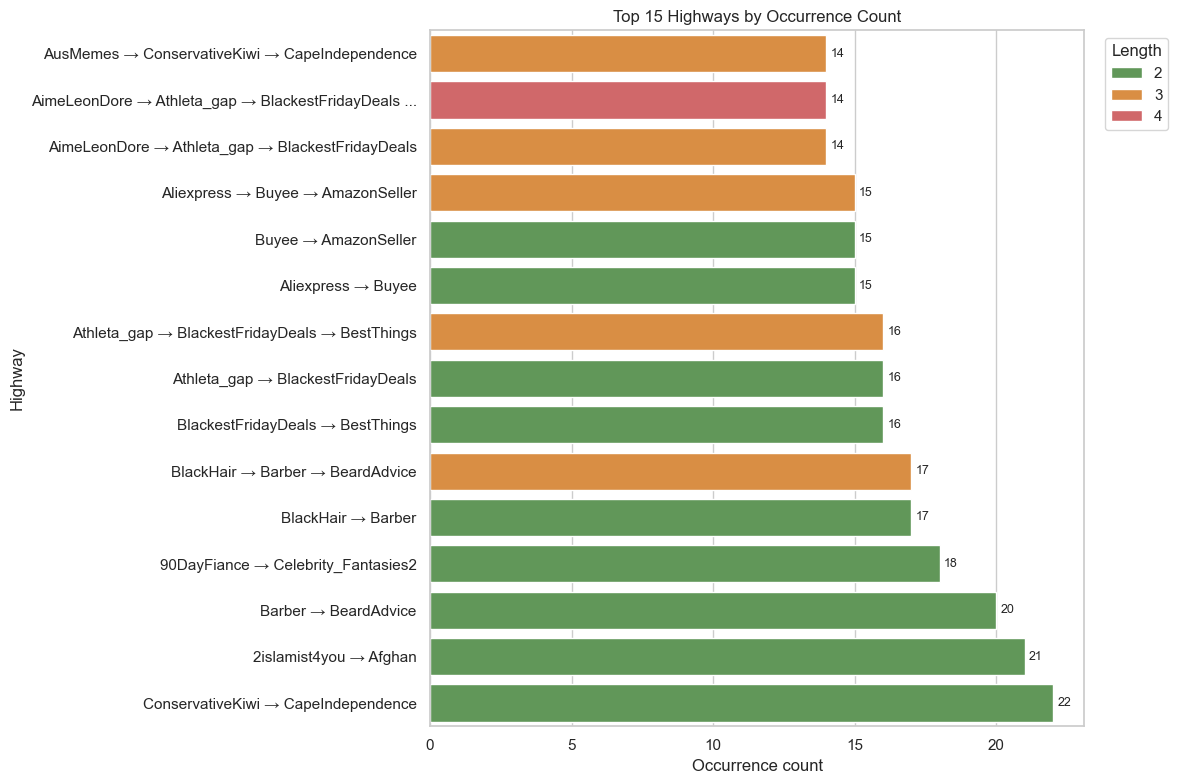

,highway_length,highway_count,total_occurrences,avg_pct_of_paths
0,2,20,292,5.770
1,3,20,210,4.321
2,4,20,124,2.781
3,5,20,68,2.178


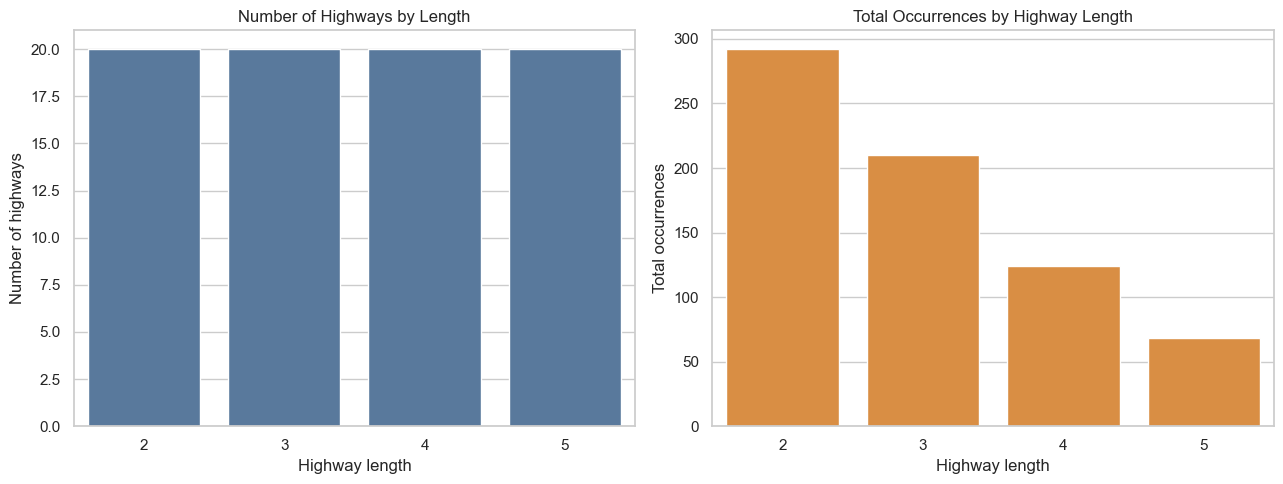

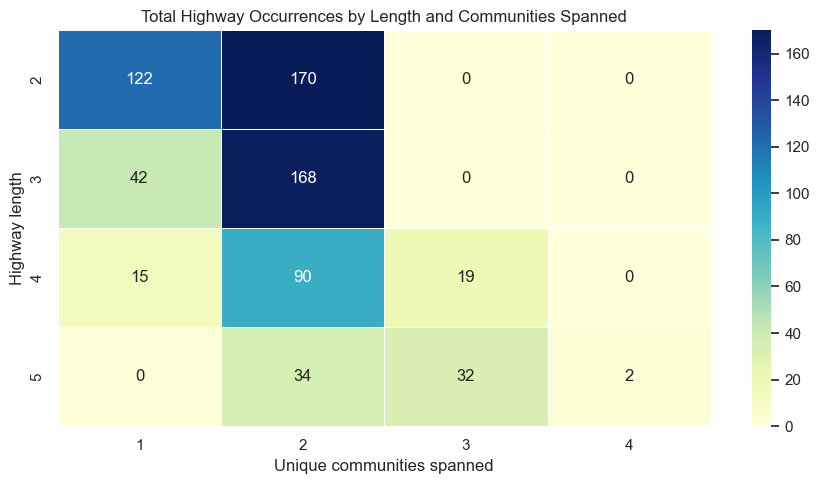

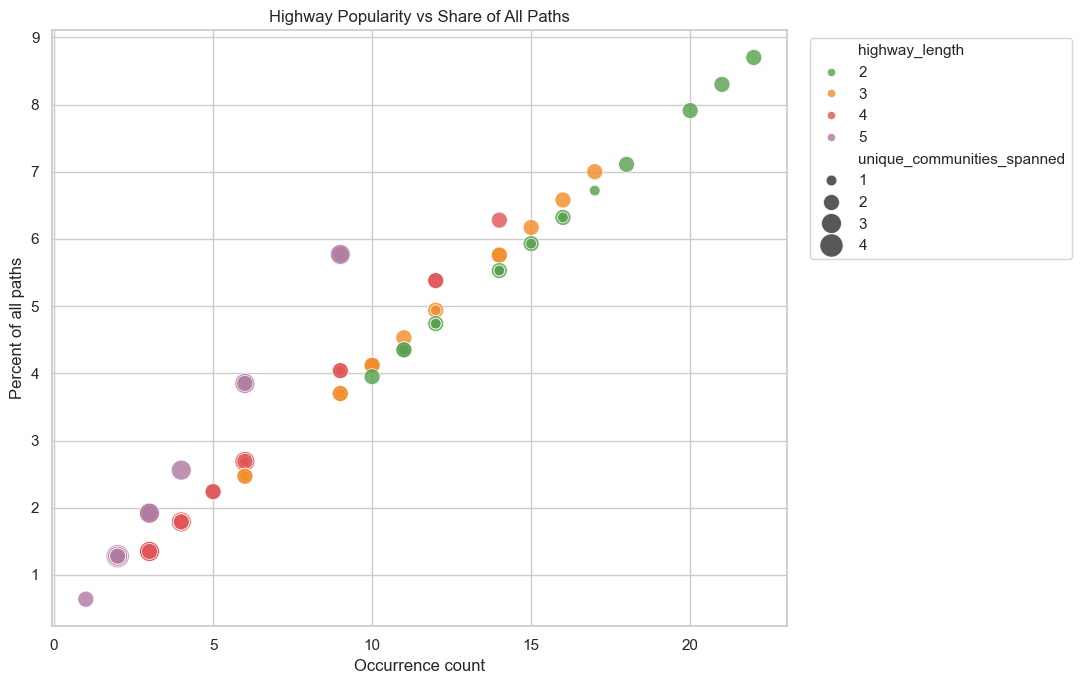

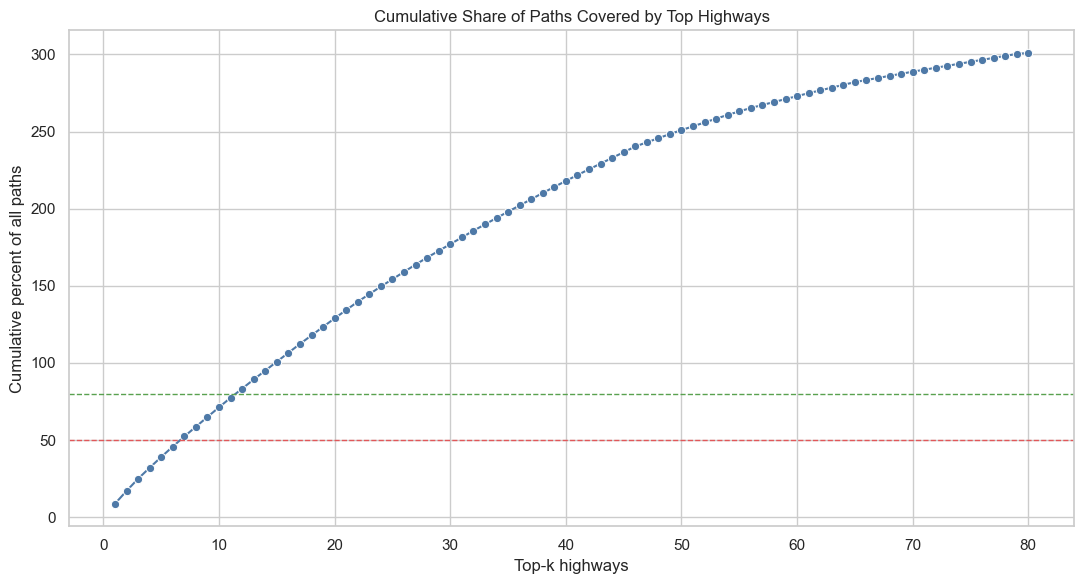

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

highway_df = pd.read_csv("result/highway_result.csv")
highway_df = highway_df.sort_values("rank").reset_index(drop=True)

required_columns = [
    "rank",
    "highway_length",
    "highway_nodes",
    "occurrence_count",
    "pct_of_paths",
    "pct_of_paths_min_length",
    "unique_communities_spanned",
]
missing_columns = [column for column in required_columns if column not in highway_df.columns]
if missing_columns:
    raise ValueError(f"Missing columns in highway_result.csv: {missing_columns}")

def shorten_label(value, max_length=52):
    value = str(value)
    return value if len(value) <= max_length else value[: max_length - 3] + "..."

highway_df["highway_label"] = highway_df["highway_nodes"].apply(shorten_label)
highway_df["cumulative_pct_of_paths"] = highway_df["pct_of_paths"].cumsum()

display(highway_df.head(10))

sns.set_theme(style="whitegrid", context="notebook")
palette = {
    1: "#4E79A7",
    2: "#59A14F",
    3: "#F28E2B",
    4: "#E15759",
    5: "#B07AA1",
}

# 1) Top highways by occurrence count.
top_n = 15
top_highways = highway_df.nlargest(top_n, "occurrence_count").sort_values("occurrence_count")

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=top_highways,
    x="occurrence_count",
    y="highway_label",
    hue="highway_length",
    dodge=False,
    palette=palette,
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3, fontsize=9)
plt.title(f"Top {top_n} Highways by Occurrence Count")
plt.xlabel("Occurrence count")
plt.ylabel("Highway")
plt.legend(title="Length", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 2) Distribution of highway lengths.
length_summary = (
    highway_df.groupby("highway_length", as_index=False)
    .agg(
        highway_count=("rank", "count"),
        total_occurrences=("occurrence_count", "sum"),
        avg_pct_of_paths=("pct_of_paths", "mean"),
    )
)
display(length_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(
    data=length_summary,
    x="highway_length",
    y="highway_count",
    color="#4E79A7",
    ax=axes[0],
)
axes[0].set_title("Number of Highways by Length")
axes[0].set_xlabel("Highway length")
axes[0].set_ylabel("Number of highways")

sns.barplot(
    data=length_summary,
    x="highway_length",
    y="total_occurrences",
    color="#F28E2B",
    ax=axes[1],
)
axes[1].set_title("Total Occurrences by Highway Length")
axes[1].set_xlabel("Highway length")
axes[1].set_ylabel("Total occurrences")
plt.tight_layout()
plt.show()

# 3) Length vs communities spanned heatmap.
heatmap_data = highway_df.pivot_table(
    index="highway_length",
    columns="unique_communities_spanned",
    values="occurrence_count",
    aggfunc="sum",
    fill_value=0,
)

plt.figure(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5)
plt.title("Total Highway Occurrences by Length and Communities Spanned")
plt.xlabel("Unique communities spanned")
plt.ylabel("Highway length")
plt.tight_layout()
plt.show()

# 4) Popularity vs path share.
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=highway_df,
    x="occurrence_count",
    y="pct_of_paths",
    hue="highway_length",
    size="unique_communities_spanned",
    sizes=(60, 280),
    palette=palette,
    alpha=0.82,
)
plt.title("Highway Popularity vs Share of All Paths")
plt.xlabel("Occurrence count")
plt.ylabel("Percent of all paths")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 5) Pareto curve: how much of all path traffic is captured by top highways.
pareto_df = highway_df.sort_values("pct_of_paths", ascending=False).reset_index(drop=True)
pareto_df["top_k"] = np.arange(1, len(pareto_df) + 1)
pareto_df["cumulative_pct_of_paths"] = pareto_df["pct_of_paths"].cumsum()

plt.figure(figsize=(11, 6))
sns.lineplot(data=pareto_df, x="top_k", y="cumulative_pct_of_paths", marker="o", color="#4E79A7")
plt.axhline(50, color="#E15759", linestyle="--", linewidth=1)
plt.axhline(80, color="#59A14F", linestyle="--", linewidth=1)
plt.title("Cumulative Share of Paths Covered by Top Highways")
plt.xlabel("Top-k highways")
plt.ylabel("Cumulative percent of all paths")
plt.tight_layout()
plt.show()
